# Feature Engineering: Elo-рейтинги

В этом ноутбуке три связанных рейтинга:

1. **Individual Elo** - индивидуальный рейтинг каждого игрока. Обновляется после каждого матча, рейтинг команды = среднее Elo двух игроков
2. **Pair Elo** - рейтинг **пары** как единого объекта, обновляется только после совместных матчей пары
3. **Margin-weighted Elo** - индивидуальный Elo, где скорость обновления `K` масштабируется на разницу по геймам в матче

Дополнительно сохраняем:
- `elo_min_matches` - минимум сыгранных матчей среди 4 игроков
- `pair_elo_min_matches` - минимум совместных матчей у двух пар
- `elo_expected_team1`, `pair_elo_expected_team1`, `mw_elo_expected_team1` - ожидаемые вероятности победы команды 1 в рамках каждого рейтинга

Результат: `data/features/elo.csv` с ключом `match_id`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")
RAW = Path("../../data/raw")

df = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
df = df.sort_values("played_at").reset_index(drop=True)
print(f"Матчей: {len(df)}")

Матчей: 2549


## 1. Individual Elo

In [2]:
def compute_individual_elo(df, K=32, initial_elo=1500):
    """Elo каждого игрока"""
    df = df.sort_values("played_at").reset_index(drop=True)
    elo = {}
    n_played = {}
    records = []

    for _, row in df.iterrows():
        p1, p2, p3, p4 = row["player_id_1"], row["player_id_2"], row["player_id_3"], row["player_id_4"]
        for p in [p1, p2, p3, p4]:
            if p not in elo:
                elo[p] = initial_elo
                n_played[p] = 0

        e1, e2 = elo[p1], elo[p2]
        e3, e4 = elo[p3], elo[p4]
        t1 = (e1 + e2) / 2
        t2 = (e3 + e4) / 2
        expected = 1 / (1 + 10 ** ((t2 - t1) / 400))
        min_n = min(n_played[p] for p in [p1, p2, p3, p4])

        records.append({
            "match_id": row["match_id"],
            "elo_p1": e1, "elo_p2": e2, "elo_p3": e3, "elo_p4": e4,
            "elo_team1": t1, "elo_team2": t2,
            "elo_diff": t1 - t2,
            "elo_expected_team1": expected,
            "elo_min_matches": min_n,
        })

        actual = 1.0 if row["winner"] == "team_1" else 0.0
        delta = K * (actual - expected)
        elo[p1] += delta; elo[p2] += delta
        elo[p3] -= delta; elo[p4] -= delta
        for p in [p1, p2, p3, p4]:
            n_played[p] += 1

    return pd.DataFrame(records), dict(elo)

In [3]:
elo_ind, final_player_elo = compute_individual_elo(df, K=32)
print(f"Матчей: {len(elo_ind)}")
print(elo_ind[["elo_team1", "elo_team2", "elo_diff", "elo_expected_team1", "elo_min_matches"]].describe())

Матчей: 2549
         elo_team1    elo_team2     elo_diff  elo_expected_team1  \
count  2549.000000  2549.000000  2549.000000         2549.000000   
mean   1613.573343  1604.680951     8.892392            0.507687   
std     187.629117   168.600381   201.883958            0.214207   
min    1344.865067  1338.625644  -748.239883            0.013292   
25%    1491.172767  1489.499094   -88.278970            0.375622   
50%    1539.048662  1538.451570     2.203183            0.503171   
75%    1686.684582  1679.552842    95.537111            0.634125   
max    2284.808535  2181.576374   872.716583            0.993463   

       elo_min_matches  
count      2549.000000  
mean         29.217732  
std          31.894832  
min           0.000000  
25%           6.000000  
50%          20.000000  
75%          42.000000  
max         220.000000  


## 2. Pair Elo

In [4]:
def _pair_key(a, b):
    return (int(min(a, b)), int(max(a, b)))


def compute_pair_elo(df, K=32, initial_elo=1500):
    """Рейтинг пары игроков как отдельного объекта"""
    df = df.sort_values("played_at").reset_index(drop=True)
    elo = {}
    n_played = {}
    records = []

    for _, row in df.iterrows():
        k1 = _pair_key(row["player_id_1"], row["player_id_2"])
        k2 = _pair_key(row["player_id_3"], row["player_id_4"])
        for k in [k1, k2]:
            if k not in elo:
                elo[k] = initial_elo
                n_played[k] = 0

        r1, r2 = elo[k1], elo[k2]
        expected = 1 / (1 + 10 ** ((r2 - r1) / 400))
        min_n = min(n_played[k1], n_played[k2])

        records.append({
            "match_id": row["match_id"],
            "pair_elo_team1": r1,
            "pair_elo_team2": r2,
            "pair_elo_diff": r1 - r2,
            "pair_elo_expected_team1": expected,
            "pair_elo_min_matches": min_n,
        })

        actual = 1.0 if row["winner"] == "team_1" else 0.0
        delta = K * (actual - expected)
        elo[k1] += delta
        elo[k2] -= delta
        n_played[k1] += 1
        n_played[k2] += 1

    return pd.DataFrame(records), dict(elo)

In [5]:
elo_pair, final_pair_elo = compute_pair_elo(df, K=32)
print(elo_pair[["pair_elo_team1", "pair_elo_team2", "pair_elo_diff", "pair_elo_expected_team1", "pair_elo_min_matches"]].describe())

       pair_elo_team1  pair_elo_team2  pair_elo_diff  pair_elo_expected_team1  \
count     2549.000000     2549.000000    2549.000000              2549.000000   
mean      1576.243980     1567.515711       8.728268                 0.505582   
std        147.598681      120.385071     161.422496                 0.170189   
min       1406.967450     1391.279166    -553.311728                 0.039730   
25%       1500.000000     1500.000000     -40.688194                 0.441711   
50%       1517.768170     1516.844247       0.000000                 0.500000   
75%       1580.714973     1583.779203      40.180948                 0.557569   
max       2165.056934     2059.117904     687.326061                 0.981230   

       pair_elo_min_matches  
count           2549.000000  
mean               7.247548  
std               14.756644  
min                0.000000  
25%                1.000000  
50%                3.000000  
75%                8.000000  
max              187.000000  


## 3. Margin-weighted Elo

In [6]:
def _games_diff(row):
    games_t1 = 0
    games_t2 = 0
    for s in [1, 2, 3]:
        g1 = row.get(f"set{s}_team1")
        g2 = row.get(f"set{s}_team2")
        if pd.notna(g1) and pd.notna(g2):
            games_t1 += g1
            games_t2 += g2
    return games_t1 - games_t2


def compute_margin_weighted_elo(df, K=32, initial_elo=1500):
    """
    Индивидуальный Elo, но K умножается на логарифм разницы геймов
    """
    df = df.sort_values("played_at").reset_index(drop=True)
    elo = {}
    records = []

    for _, row in df.iterrows():
        p1, p2, p3, p4 = row["player_id_1"], row["player_id_2"], row["player_id_3"], row["player_id_4"]
        for p in [p1, p2, p3, p4]:
            if p not in elo:
                elo[p] = initial_elo

        t1 = (elo[p1] + elo[p2]) / 2
        t2 = (elo[p3] + elo[p4]) / 2
        expected = 1 / (1 + 10 ** ((t2 - t1) / 400))

        records.append({
            "match_id": row["match_id"],
            "mw_elo_team1": t1,
            "mw_elo_team2": t2,
            "mw_elo_diff": t1 - t2,
            "mw_elo_expected_team1": expected,
        })

        actual = 1.0 if row["winner"] == "team_1" else 0.0
        abs_margin = abs(_games_diff(row))
        # Масштаб: log(1 + margin), чтобы не было резких скачков при 6-0 vs 6-4
        multiplier = np.log1p(abs_margin) if abs_margin > 0 else 1.0
        delta = K * multiplier * (actual - expected)
        elo[p1] += delta; elo[p2] += delta
        elo[p3] -= delta; elo[p4] -= delta

    return pd.DataFrame(records), dict(elo)

In [7]:
elo_mw, _ = compute_margin_weighted_elo(df, K=16)  # K меньше, т.к. множитель увеличивает шаг
print(elo_mw[["mw_elo_team1", "mw_elo_team2", "mw_elo_diff", "mw_elo_expected_team1"]].describe())

       mw_elo_team1  mw_elo_team2  mw_elo_diff  mw_elo_expected_team1
count   2549.000000   2549.000000  2549.000000            2549.000000
mean    1611.846407   1602.716647     9.129760               0.508024
std      187.273862    168.789490   203.272612               0.214262
min     1366.356662   1353.504473  -750.169063               0.013147
25%     1491.040188   1489.203210   -84.290159               0.381022
50%     1537.336425   1535.143053     3.793900               0.505460
75%     1678.728130   1670.491446    93.352819               0.631203
max     2280.765069   2184.928224   857.578105               0.992872


## Примеры

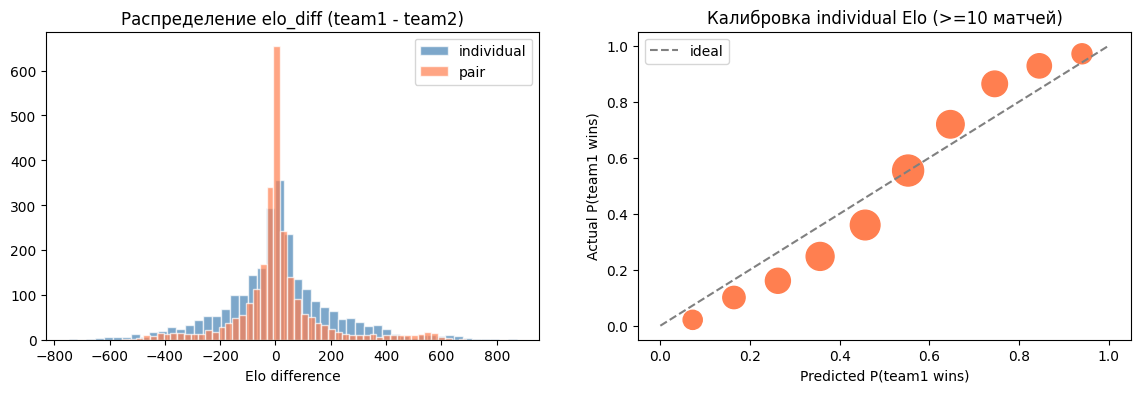

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(elo_ind["elo_diff"], bins=50, color="steelblue", edgecolor="white", alpha=0.7, label="individual")
axes[0].hist(elo_pair["pair_elo_diff"], bins=50, color="coral", edgecolor="white", alpha=0.7, label="pair")
axes[0].set_title("Распределение elo_diff (team1 - team2)")
axes[0].set_xlabel("Elo difference")
axes[0].legend()

check = df[["match_id", "winner"]].merge(elo_ind[["match_id", "elo_expected_team1", "elo_min_matches"]], on="match_id")
check = check[check["elo_min_matches"] >= 10]
check["actual"] = (check["winner"] == "team_1").astype(float)
check["bin"] = pd.cut(check["elo_expected_team1"], bins=10)
cal = check.groupby("bin", observed=True).agg(
    predicted=("elo_expected_team1", "mean"),
    actual=("actual", "mean"),
    count=("actual", "size"),
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="ideal")
axes[1].scatter(cal["predicted"], cal["actual"], s=cal["count"] * 2, color="coral")
axes[1].set_title("Калибровка individual Elo (>=10 матчей)")
axes[1].set_xlabel("Predicted P(team1 wins)")
axes[1].set_ylabel("Actual P(team1 wins)")
axes[1].legend()

plt.show()

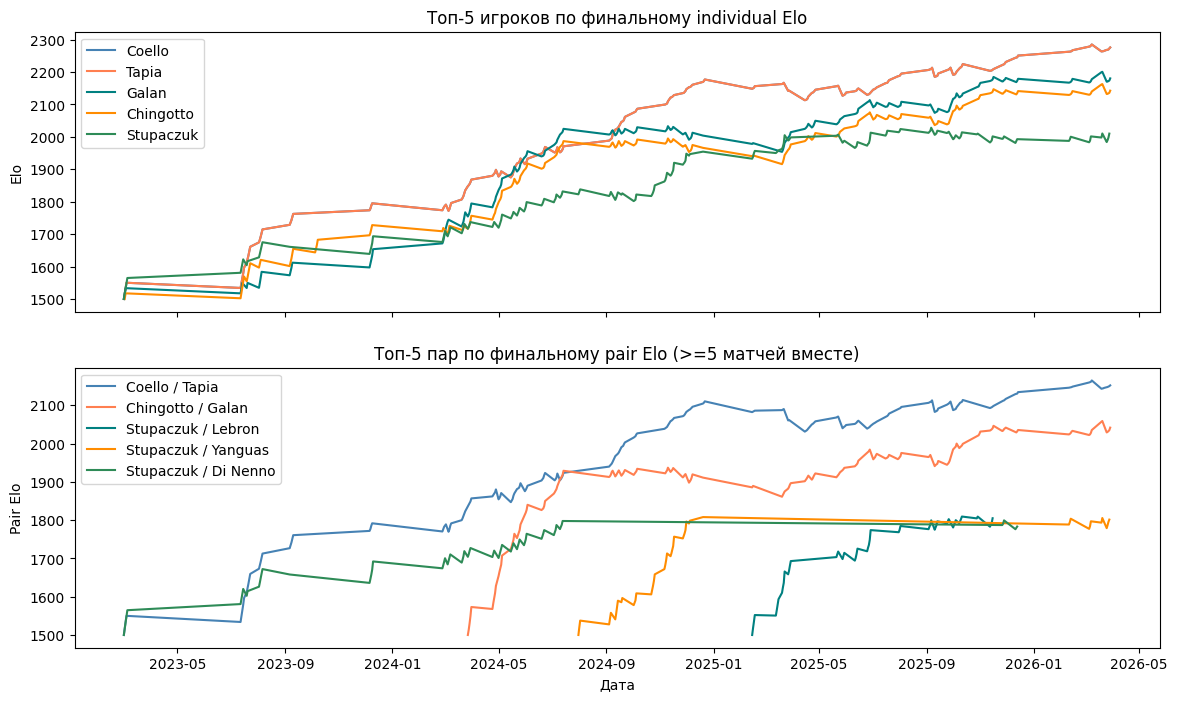

In [9]:
# Динамика Elo: топ-5 игроков и топ-5 пар
players = pd.read_csv(RAW / "men/players.csv")
id_to_name = players.set_index("player_id")["short_name"].to_dict()

merged = df.merge(elo_ind, on="match_id")
merged_pair = df.merge(elo_pair, on="match_id")

player_hist = []
for _, r in merged.iterrows():
    for pid_col, elo_col in [("player_id_1", "elo_p1"), ("player_id_2", "elo_p2"),
                              ("player_id_3", "elo_p3"), ("player_id_4", "elo_p4")]:
        player_hist.append({"played_at": r["played_at"], "player_id": r[pid_col], "elo_pre": r[elo_col]})
player_hist = pd.DataFrame(player_hist)

top_players = [pid for pid, _ in sorted(final_player_elo.items(), key=lambda x: x[1], reverse=True)[:5]]

pair_hist = []
for _, r in merged_pair.iterrows():
    k1 = _pair_key(r["player_id_1"], r["player_id_2"])
    k2 = _pair_key(r["player_id_3"], r["player_id_4"])
    pair_hist.append({"played_at": r["played_at"], "pair": k1, "elo_pre": r["pair_elo_team1"]})
    pair_hist.append({"played_at": r["played_at"], "pair": k2, "elo_pre": r["pair_elo_team2"]})
pair_hist = pd.DataFrame(pair_hist)

pair_counts = pair_hist.groupby("pair").size()
eligible_pairs = pair_counts[pair_counts >= 5].index
top_pairs = sorted(
    [(k, v) for k, v in final_pair_elo.items() if k in eligible_pairs],
    key=lambda x: x[1], reverse=True
)[:5]
top_pairs = [p for p, _ in top_pairs]

colors = ["steelblue", "coral", "teal", "darkorange", "seagreen"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, pid in enumerate(top_players):
    sub = player_hist[player_hist["player_id"] == pid].sort_values("played_at")
    axes[0].plot(sub["played_at"], sub["elo_pre"], label=id_to_name.get(pid, str(pid)), color=colors[i])
axes[0].set_title("Топ-5 игроков по финальному individual Elo")
axes[0].set_ylabel("Elo")
axes[0].legend(loc="best")

for i, pair in enumerate(top_pairs):
    sub = pair_hist[pair_hist["pair"] == pair].sort_values("played_at")
    a, b = pair
    label = f"{id_to_name.get(a, a)} / {id_to_name.get(b, b)}"
    axes[1].plot(sub["played_at"], sub["elo_pre"], label=label, color=colors[i])
axes[1].set_title("Топ-5 пар по финальному pair Elo (>=5 матчей вместе)")
axes[1].set_ylabel("Pair Elo")
axes[1].set_xlabel("Дата")
axes[1].legend(loc="best")

plt.show()

## Сохранение

In [11]:
elo_all = elo_ind.merge(elo_pair, on="match_id").merge(elo_mw, on="match_id")
print(f"Итого признаков: {elo_all.shape[1] - 1}, матчей: {len(elo_all)}")

out_path = FEATURES / "elo.csv"
elo_all.to_csv(out_path, index=False)

Итого признаков: 18, матчей: 2549
